# Ensemble Learning || Gradient Boosting - Regression 

### Import Libraries 

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load and Explore the Dataset

Use the **California Housing Dataset** from scikit-learn.

- **Task**: Predict median house prices
- **Features**: 8 numerical features (income, house age, rooms, etc.)
- **Target**: Median house value (in units of $100,000)

In [79]:
# Load the dataset
housing = fetch_california_housing()

# Convert to a DataFrame for easy viewing
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target_Price'] = housing.target

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target_Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [80]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Missing values per column:
MedInc          0
HouseAge        0
AveRooms        0
AveBedrms       0
Population      0
AveOccup        0
Latitude        0
Longitude       0
Target_Price    0
dtype: int64

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target_Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Correlation Heatmap

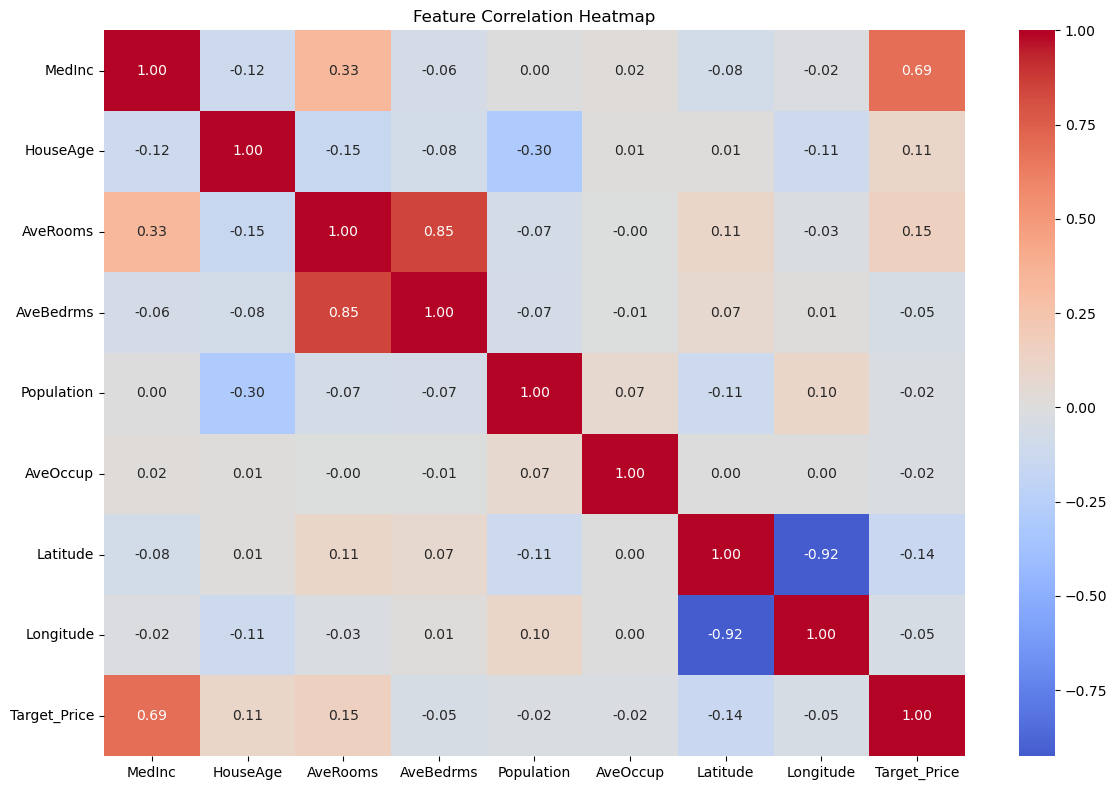

In [82]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


### Target Variable Distribution 

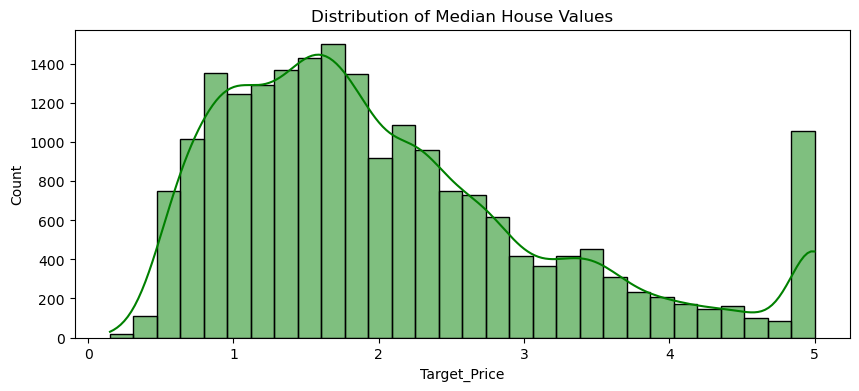

In [84]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Target_Price'], kde=True, bins=30,color='green')
plt.title('Distribution of Median House Values')
plt.xlabel('Target_Price')
plt.show()

### Prepare the Data

Split the data into:
- **X** : Feature columns (input)
- **y** : Target column (output we want to predict)

Then split into training and testing sets.

In [86]:
# Separate features (X) and target (y)
X = df.drop('Target_Price', axis=1)   
y = df['Target_Price']                 

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ── Scale Features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)       # transform test only

Training samples: 16512
Testing samples : 4128


###  Build the model

In [88]:
# ── Create Gradient Boosting Regressor 
gb_reg = GradientBoostingRegressor(
    n_estimators=100,      # 100 trees to build one after another
    learning_rate=0.1,     # shrinkage factor for each tree's contribution
    max_depth=3,           # keep trees shallow to avoid overfitting
    subsample=1.0,         # use 100% of data per tree
    loss='squared_error',  # minimize (actual - predicted)² — MSE loss
    min_samples_split=2,   # min samples required to split a node
    min_samples_leaf=1,    # min samples in each leaf
    random_state=42
)

# ── Train the model
gb_reg.fit(X_train_scaled, y_train)

# ── Make Predictions 
y_pred = gb_reg.predict(X_test_scaled)

###  Predict & evaluate

MAE  : 0.3717
MSE  : 0.2940
RMSE : 0.5422
R²   : 0.7756



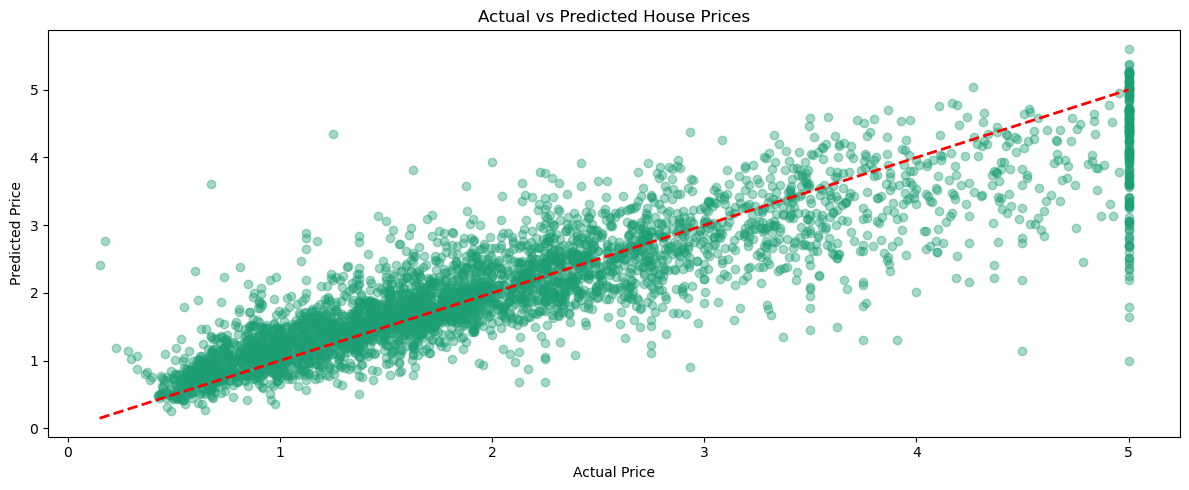

In [90]:
# ── Regression Metrics 
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)                       # Root MSE — in original units
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")    # Mean Absolute Error
print(f"MSE  : {mse:.4f}")    # Mean Squared Error
print(f"RMSE : {rmse:.4f}")   # Root MSE 
print(f"R²   : {r2:.4f}\n")    # R² — closer to 1.0 = better

# ── Actual vs Predicted Plot 
plt.figure(figsize=(12,5))
plt.scatter(y_test, y_pred, alpha=0.4, color='#1D9E75')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # perfect line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

###  Residual analysis

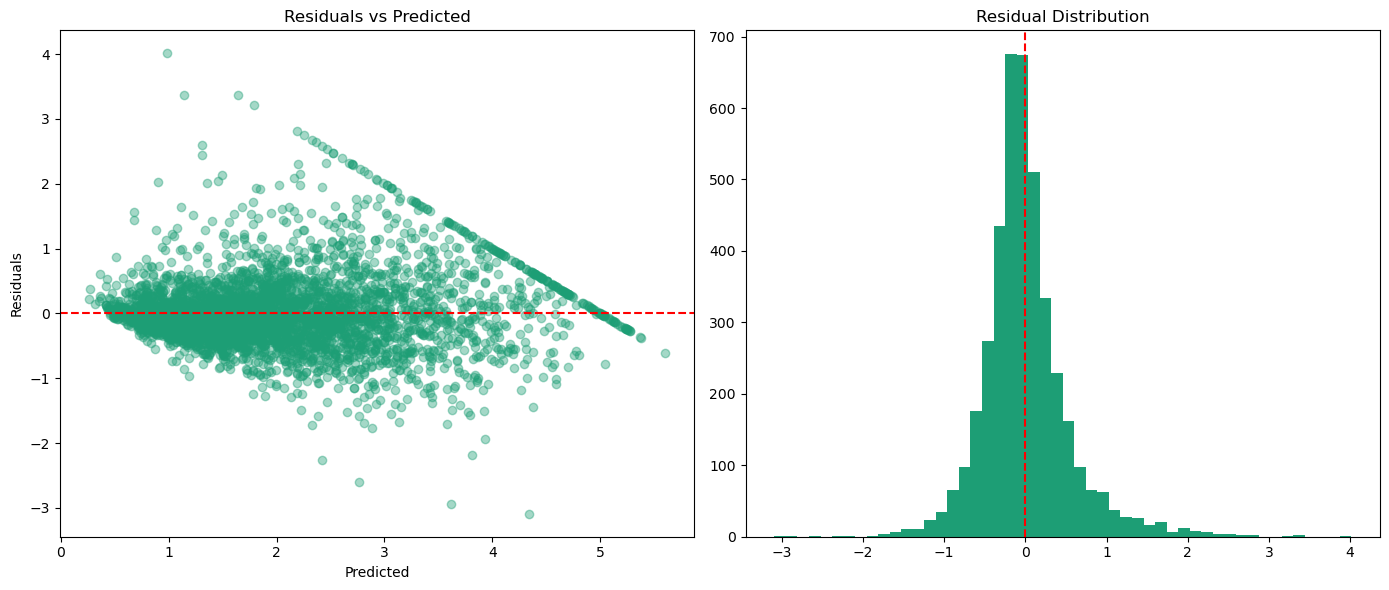

In [92]:
# Calculate residuals
residuals = y_test - y_pred

# Residuals vs Predicted
plt.figure(figsize=(14,6))
plt.subplot(121)
plt.scatter(y_pred, residuals, alpha=0.4,color='#1D9E75')
plt.axhline(0, linestyle='--',color ='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

# Residual distribution
plt.subplot(122)
plt.hist(residuals, bins=50,color='#1D9E75')
plt.axvline(0, linestyle='--',color = 'red')
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

### Feature importance

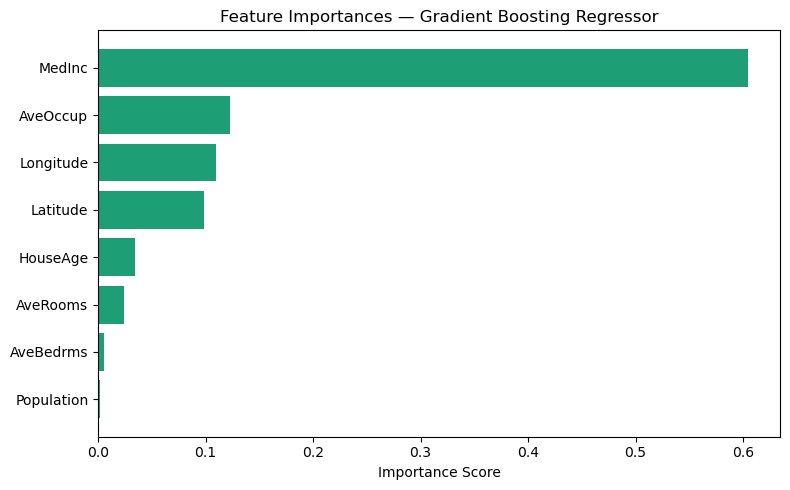

In [94]:
 
# ── Feature Importances 
importances  = gb_reg.feature_importances_
feature_names = housing.feature_names

# Sort by importance
sorted_idx = np.argsort(importances)

# ── Horizontal bar chart 
plt.figure(figsize=(8, 5))
plt.barh(
    [feature_names[i] for i in sorted_idx],
    [importances[i]   for i in sorted_idx],
    color='#1D9E75'
)
plt.xlabel('Importance Score')
plt.title('Feature Importances — Gradient Boosting Regressor')
plt.tight_layout()
plt.show()

### Cross Validation 

In [96]:
# ── 5-Fold Cross Validation 
cv_scores = cross_val_score(
    gb_reg,
    X_train_scaled, y_train,
    cv=5,
    scoring='r2'           # R² for regression
)

print("CV R² Scores:", cv_scores.round(4))
print(f"Mean R²     : {cv_scores.mean():.4f}")
print(f"Std Dev     : {cv_scores.std():.4f}")
# Low std dev = consistent, reliable model

CV R² Scores: [0.7865 0.7875 0.7921 0.7837 0.7831]
Mean R²     : 0.7866
Std Dev     : 0.0032
